In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
from src.config import read_data

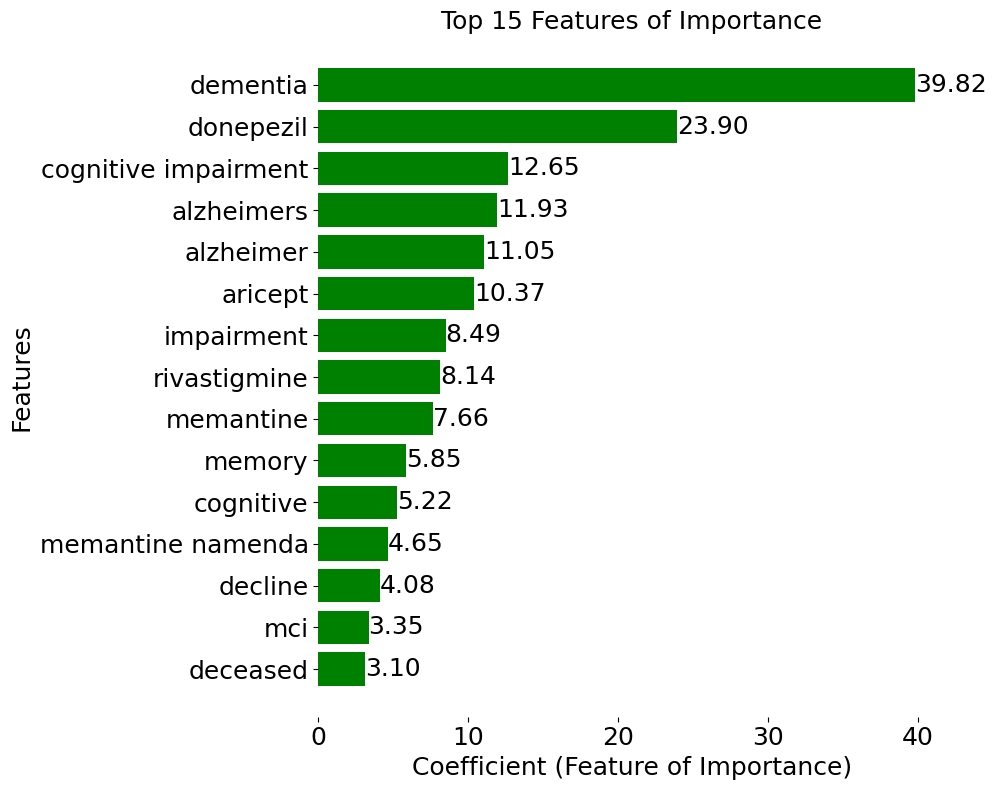

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load DataFrame from CSV file
# df_positive_coefs = pd.read_csv('/home/niels/cdac Dropbox/Niels Turley/codes/data/positive_coefficients.csv')
df_positive_coefs= read_data("positive_coefficients.csv", from_web=True)

# Filter out only positive coefficients
df_positive_coefs = df_positive_coefs[df_positive_coefs['Coefficient'] > 0]

# Sorting by magnitude (absolute value)
df_positive_coefs_sorted = df_positive_coefs.sort_values(by='Coefficient', ascending=False)

# Selecting top features for visualization
top_15_features_positive = df_positive_coefs_sorted.head(15)

# Plotting feature importance as bar chart
plt.figure(figsize=(10, 8))
ax = plt.gca()
positive_bars = plt.barh(top_15_features_positive['Feature'], top_15_features_positive['Coefficient'], color='green')

# Invert y-axis to have the highest coefficient at the top
ax.invert_yaxis()

# Remove the outer frame (spines)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

# Set titles and labels with increased font sizes
plt.title('Top 15 Features of Importance', fontsize=18)
plt.xlabel('Coefficient (Feature of Importance)', fontsize=18)
plt.ylabel('Features', fontsize=18)

# Increase font size for tick labels
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Add text labels to bars
for bar in positive_bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f'{width:.2f}', va='center', ha='left', fontsize=18)

plt.tight_layout()

plt.show()